# [KHANG] EDA & Data Preprocessing

**Mục tiêu:** Tải, làm sạch, tối ưu bộ nhớ và phân tích trực quan bộ dữ liệu CIC-IDS2017.

**Đầu vào:** 8 file CSV trong `data/raw/`  
**Đầu ra:** `data/processed/cleaned.csv`

## [KHANG] - Bước 1: Import thư viện

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Đường dẫn gốc dự án
ROOT = Path('..').resolve()
RAW_DIR = ROOT / 'data' / 'raw'
PROCESSED_DIR = ROOT / 'data' / 'processed'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print('Thư viện đã được tải thành công.')
print(f'RAW_DIR: {RAW_DIR}')
print(f'PROCESSED_DIR: {PROCESSED_DIR}')

Thư viện đã được tải thành công.
RAW_DIR: D:\javabtap\Network-Intrusion-Detection-ML\data\raw
PROCESSED_DIR: D:\javabtap\Network-Intrusion-Detection-ML\data\processed


## [KHANG] - Bước 2: Tải và ghép 8 file CSV

In [2]:
csv_files = sorted(RAW_DIR.glob('*.csv'))
print(f'Tìm thấy {len(csv_files)} file CSV:')
for f in csv_files:
    print(f'  {f.name}')

if len(csv_files) == 0:
    raise FileNotFoundError(
        'Không tìm thấy file CSV trong data/raw/. '
        'Hãy tải CIC-IDS2017 và đặt vào thư mục data/raw/'
    )

# Đọc và ghép tất cả file
dfs = []
for f in csv_files:
    df_part = pd.read_csv(f, low_memory=False, on_bad_lines='skip', encoding='utf-8', encoding_errors='replace')
    print(f'  {f.name}: {df_part.shape}')
    dfs.append(df_part)

df = pd.concat(dfs, ignore_index=True)
print(f'\nDataFrame sau khi ghép: {df.shape}')

Tìm thấy 8 file CSV:
  Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
  Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
  Friday-WorkingHours-Morning.pcap_ISCX.csv
  Monday-WorkingHours.pcap_ISCX.csv
  Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
  Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
  Tuesday-WorkingHours.pcap_ISCX.csv
  Wednesday-workingHours.pcap_ISCX.csv
  Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv: (225745, 79)
  Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv: (286467, 79)
  Friday-WorkingHours-Morning.pcap_ISCX.csv: (191033, 79)
  Monday-WorkingHours.pcap_ISCX.csv: (529918, 79)
  Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv: (288602, 79)
  Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv: (170366, 79)
  Tuesday-WorkingHours.pcap_ISCX.csv: (445909, 79)
  Wednesday-workingHours.pcap_ISCX.csv: (692703, 79)

DataFrame sau khi ghép: (2830743, 79)


## [KHANG] - Bước 3: Làm sạch dữ liệu

In [3]:
# Xóa khoảng trắng trong tên cột
df.columns = df.columns.str.strip()
print('Tên cột sau khi strip:')
print(df.columns.tolist())

# Thay thế inf và -inf bằng NaN — xử lý từng cột để tiết kiệm RAM
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    mask = ~np.isfinite(df[col])
    if mask.any():
        df[col] = df[col].where(np.isfinite(df[col]), np.nan)
print(f'\nSố giá trị NaN trước khi fill: {df.isna().sum().sum()}')

# Fill NaN bằng median của từng cột số — từng cột để tiết kiệm RAM
for col in numeric_cols:
    if df[col].isna().any():
        df[col] = df[col].fillna(df[col].median())
print(f'Số giá trị NaN sau khi fill: {df.isna().sum().sum()}')

# Xóa cột có phương sai bằng 0 (không có thông tin)
zero_var_cols = [c for c in numeric_cols if df[c].var() == 0]
print(f'\nCột zero-variance bị xóa ({len(zero_var_cols)}): {zero_var_cols}')
df.drop(columns=zero_var_cols, inplace=True)


print(f'Shape sau làm sạch: {df.shape}')

Tên cột sau khi strip:
['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag 

## [KHANG] - Bước 4: Tối ưu hóa bộ nhớ

In [4]:
def memory_usage_mb(df):
    return df.memory_usage(deep=True).sum() / 1024 ** 2

mem_before = memory_usage_mb(df)
print(f'Bộ nhớ TRƯỚC tối ưu: {mem_before:.2f} MB')

# Downcast số nguyên: thử uint8 trước, rồi int16
for col in df.select_dtypes(include=['int64']).columns:
    col_min, col_max = df[col].min(), df[col].max()
    if col_min >= 0 and col_max <= 255:
        df[col] = df[col].astype(np.uint8)
    elif col_min >= -32768 and col_max <= 32767:
        df[col] = df[col].astype(np.int16)

# Downcast float64 → float32
for col in df.select_dtypes(include=['float64']).columns:
    df[col] = df[col].astype(np.float32)

mem_after = memory_usage_mb(df)
print(f'Bộ nhớ SAU  tối ưu: {mem_after:.2f} MB')
print(f'Tiết kiệm: {mem_before - mem_after:.2f} MB ({(1 - mem_after/mem_before)*100:.1f}%)')
print(f'\nShape hiện tại: {df.shape}')

Bộ nhớ TRƯỚC tối ưu: 1661.09 MB
Bộ nhớ SAU  tối ưu: 1096.87 MB
Tiết kiệm: 564.22 MB (34.0%)

Shape hiện tại: (2830743, 71)


## [KHANG] - Bước 5: Thông tin tổng quan dữ liệu

In [5]:
print('=== Thông tin DataFrame ===')
print(f'Shape: {df.shape}')
print(f'\nSố kiểu dữ liệu:')
print(df.dtypes.value_counts())
print(f'\nGiá trị thiếu: {df.isna().sum().sum()}')

print('\n=== Phân phối nhãn (Label) ===')
label_counts = df['Label'].value_counts()
print(label_counts.to_string())

=== Thông tin DataFrame ===
Shape: (2830743, 71)

Số kiểu dữ liệu:
int64      29
float32    24
uint8      11
int16       6
str         1
Name: count, dtype: int64

Giá trị thiếu: 0

=== Phân phối nhãn (Label) ===
Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11


## [KHANG] - Bước 6: Trực quan hóa EDA

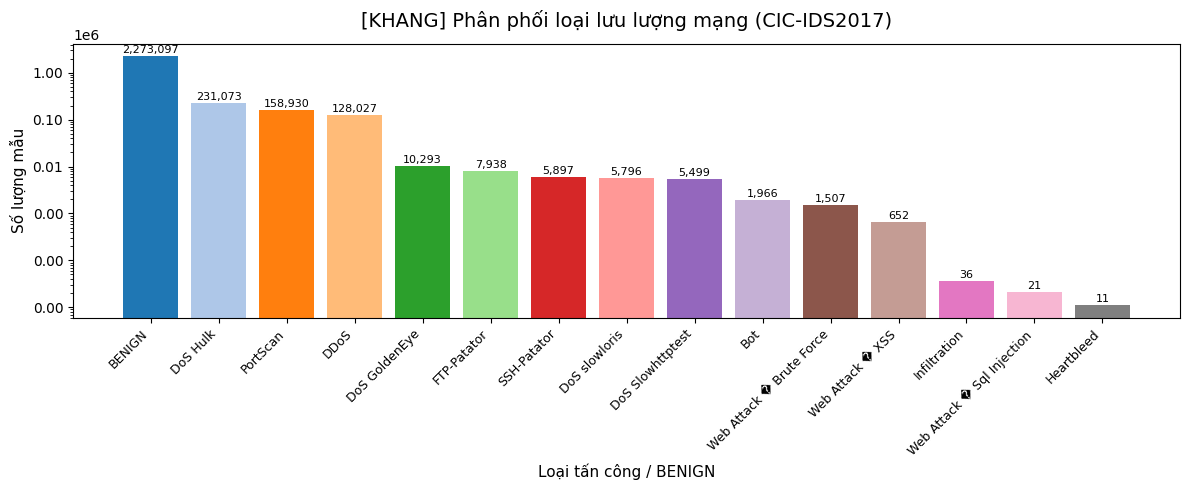

Đã lưu: label_distribution.png


In [6]:
# --- Biểu đồ phân phối loại tấn công ---
label_counts = df['Label'].value_counts()

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(label_counts.index, label_counts.values,
              color=plt.cm.tab20.colors[:len(label_counts)])
ax.set_title('[KHANG] Phân phối loại lưu lượng mạng (CIC-IDS2017)', fontsize=14, pad=12)
ax.set_xlabel('Loại tấn công / BENIGN', fontsize=11)
ax.set_ylabel('Số lượng mẫu', fontsize=11)
ax.set_yscale('log')
ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
plt.xticks(rotation=45, ha='right', fontsize=9)

for bar, val in zip(bars, label_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.05,
            f'{val:,}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'label_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print('Đã lưu: label_distribution.png')

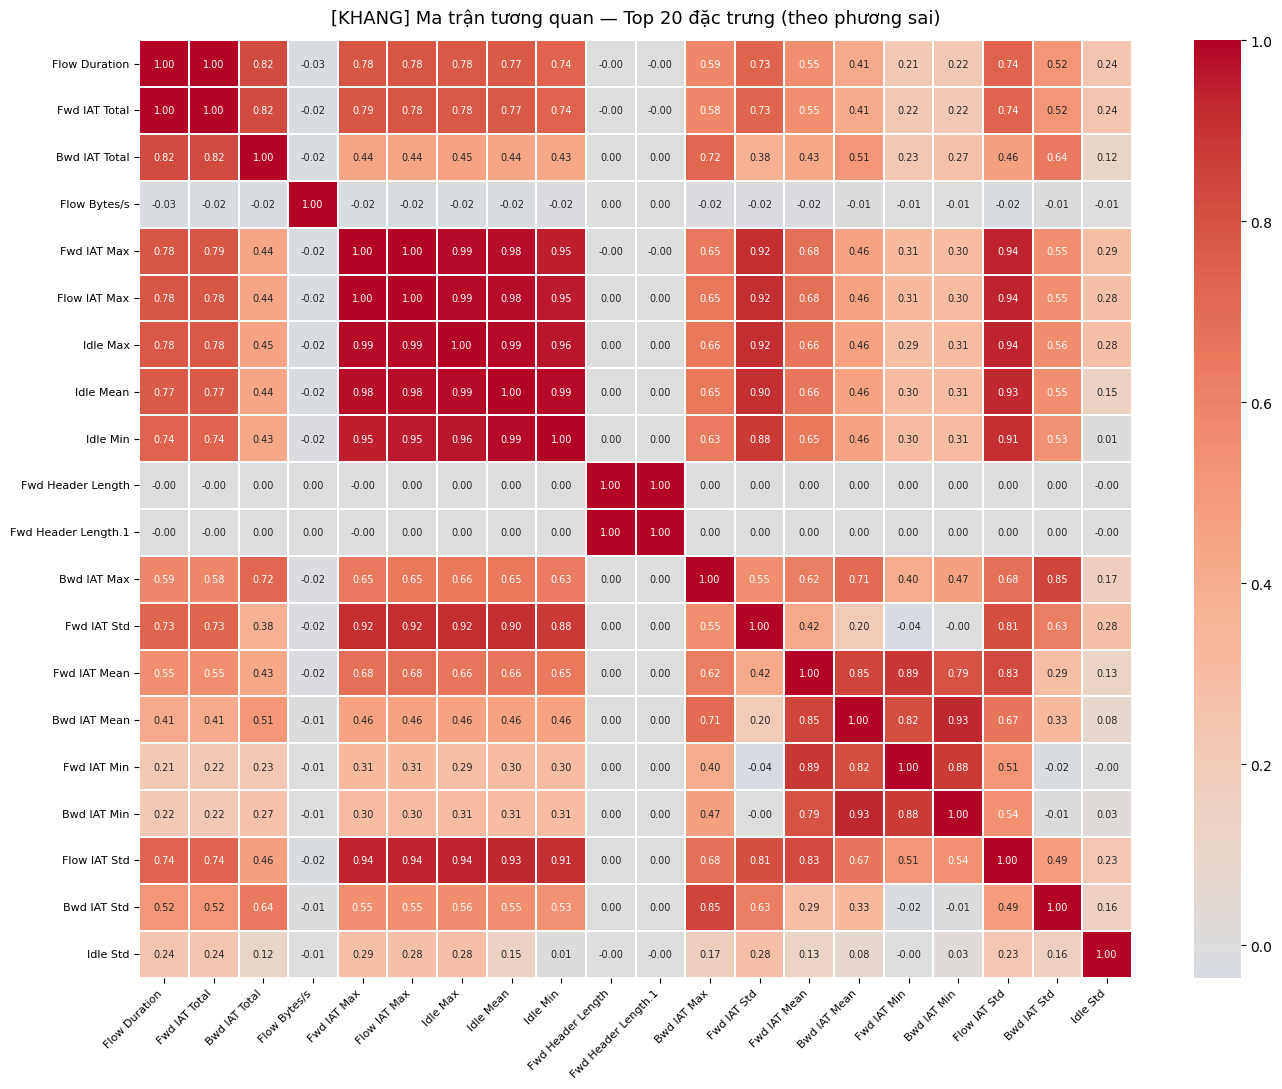

Đã lưu: correlation_heatmap.png


In [7]:
# --- Heatmap tương quan top-20 đặc trưng theo phương sai ---
numeric_df = df.select_dtypes(include=[np.number])
top20_cols = numeric_df.var().nlargest(20).index.tolist()

corr_matrix = numeric_df[top20_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    linewidths=0.3, linecolor='white',
    ax=ax, annot_kws={'size': 7}
)
ax.set_title('[KHANG] Ma trận tương quan — Top 20 đặc trưng (theo phương sai)', fontsize=13, pad=12)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()
print('Đã lưu: correlation_heatmap.png')

## [KHANG] - Bước 7: Lưu dữ liệu đã làm sạch

In [8]:
output_path = PROCESSED_DIR / 'cleaned.csv'
df.to_csv(output_path, index=False)
print(f'Đã lưu dữ liệu sạch: {output_path}')
print(f'Shape cuối cùng: {df.shape}')
print(f'Kích thước file: {output_path.stat().st_size / 1024 / 1024:.1f} MB')
print('\n✓ [KHANG] Hoàn thành EDA & Preprocessing!')

Đã lưu dữ liệu sạch: D:\javabtap\Network-Intrusion-Detection-ML\data\processed\cleaned.csv
Shape cuối cùng: (2830743, 71)
Kích thước file: 823.0 MB

✓ [KHANG] Hoàn thành EDA & Preprocessing!
